In [1]:
# Cell 1 — Setup + Diagnostic
from google.cloud import bigquery
import pandas as pd

PROJECT_ID = "fyxical-poc"
DATASET = "fyxical_poc"

client = bigquery.Client(project=PROJECT_ID)

# Diagnostic
print("1. Testing connection...")
test = client.query("SELECT 1 as test").to_dataframe()
print(f"✅ Connection OK: {test}")

print("\n2. Listing datasets...")
for ds in client.list_datasets():
    print(f"   📁 {ds.dataset_id}")

print("\n3. Listing tables in fyxical_poc...")
for table in client.list_tables(DATASET):
    print(f"   📋 {table.table_id}")

1. Testing connection...
✅ Connection OK:    test
0     1

2. Listing datasets...
   📁 fyxical_poc

3. Listing tables in fyxical_poc...
   📋 patient_intake


In [2]:
# 02 - Exploratory Data Analysis

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ID = "fyxical-poc"
DATASET = "fyxical_poc"
client = bigquery.Client(project=PROJECT_ID)

patients = client.query(f"""
    SELECT * FROM `{PROJECT_ID}.{DATASET}.patient_intake`
""").to_dataframe()

print(f"✅ {len(patients)} patients loaded")

✅ 500 patients loaded


In [3]:
print("=== DEMOGRAPHICS ===")
print(f"\nAge:\n  Mean: {patients['age'].mean():.1f}  |  Min: {patients['age'].min()}  |  Max: {patients['age'].max()}")
print(f"\nSex:\n{patients['sex'].value_counts()}")
print(f"\nRace/Ethnicity:\n{patients['race_ethnicity'].value_counts()}")
print(f"\nOccupation Type:\n{patients['occupation_type'].value_counts()}")
print(f"\nWork-Related Injury:\n{patients['work_related_injury'].value_counts()}")
print(f"\nCensus Region:\n{patients['region_census'].value_counts()}")

=== DEMOGRAPHICS ===

Age:
  Mean: 48.4  |  Min: 18  |  Max: 80

Sex:
sex
Female    288
Male      212
Name: count, dtype: int64

Race/Ethnicity:
race_ethnicity
White              283
Black               99
Hispanic_Latino     88
Other               15
Asian               15
Name: count, dtype: int64

Occupation Type:
occupation_type
Desk_office     178
Manual_labor    121
Service         117
Healthcare       62
Other            22
Name: count, dtype: int64

Work-Related Injury:
work_related_injury
No        314
Yes       132
Unsure     54
Name: count, dtype: int64

Census Region:
region_census
South        212
West         111
Midwest      106
Northeast     71
Name: count, dtype: int64


In [4]:
print("=== PAIN PROFILE ===")
print(f"\nDuration Category:\n{patients['pain_duration_category'].value_counts()}")
print(f"\nSeverity Category:\n{patients['pain_severity_category'].value_counts()}")
print(f"\nDisability Category:\n{patients['osw_baseline_disability_category'].value_counts()}")
print(f"\nAvg Pain Severity Score: {patients['pain_severity_score_0_10'].mean():.2f}/10")
print(f"Avg OSW Disability %: {patients['osw_baseline_percent_disability'].mean():.1f}%")
print(f"Avg Pain Duration: {patients['pain_duration_weeks'].mean():.1f} weeks")

=== PAIN PROFILE ===

Duration Category:
pain_duration_category
Chronic     192
Subacute    167
Acute       141
Name: count, dtype: int64

Severity Category:
pain_severity_category
Moderate    227
Severe      188
Mild         85
Name: count, dtype: int64

Disability Category:
osw_baseline_disability_category
Severe      222
Moderate    144
Crippled    105
Minimal      29
Name: count, dtype: int64

Avg Pain Severity Score: 5.78/10
Avg OSW Disability %: 44.5%
Avg Pain Duration: 15.0 weeks


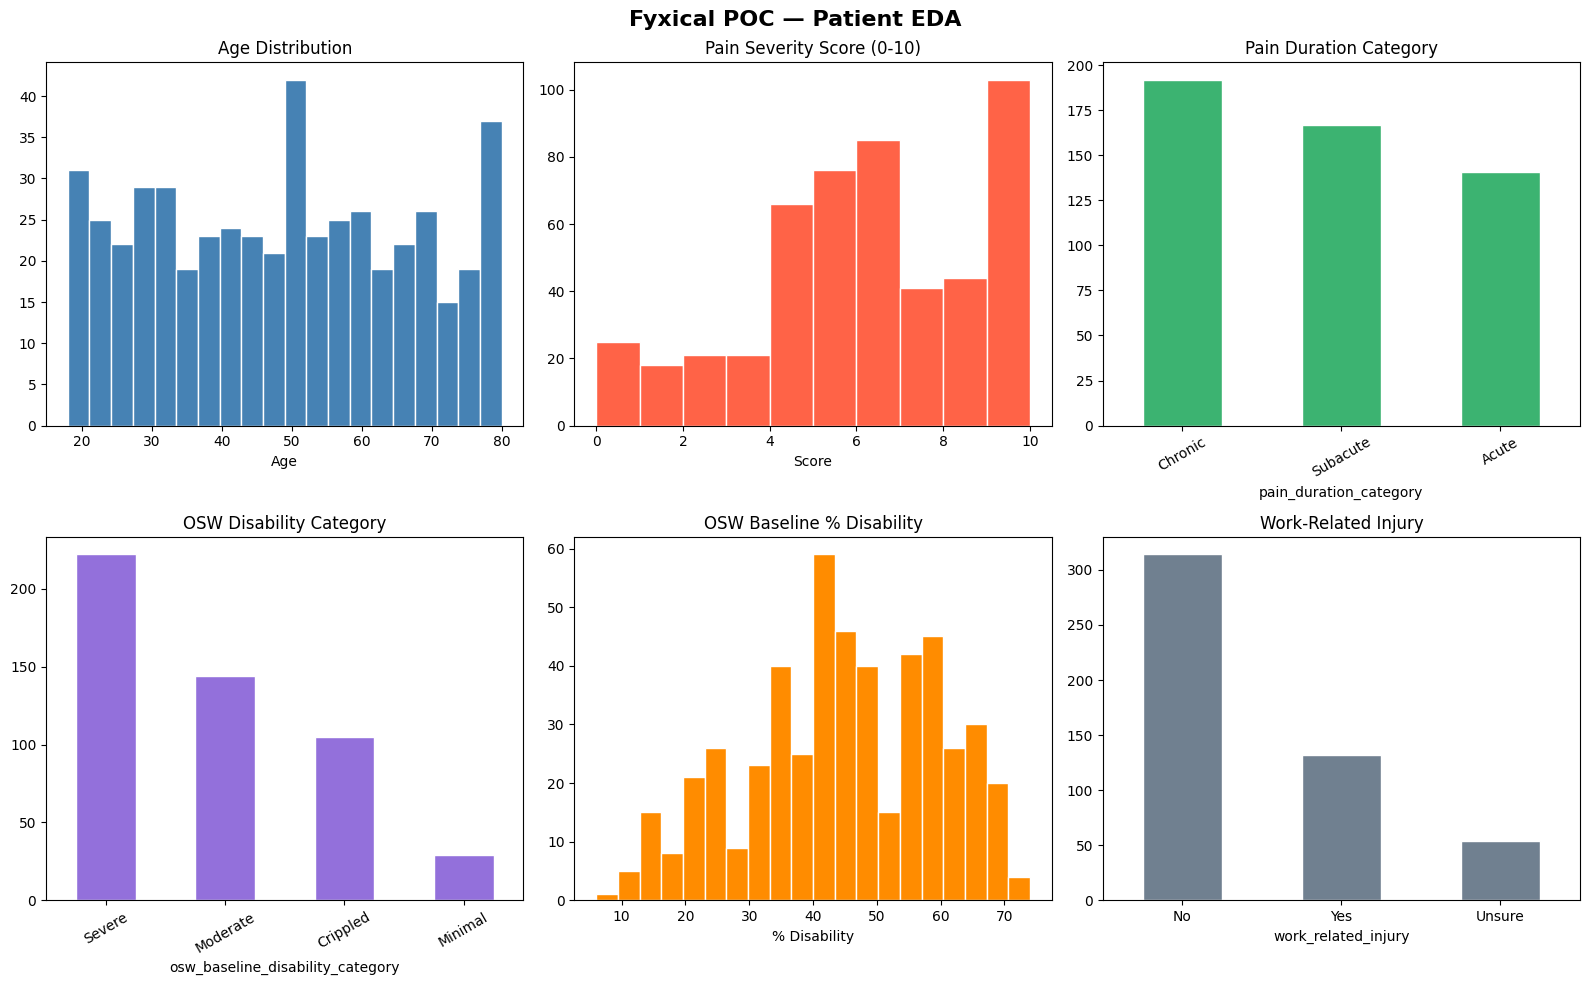

✅ Chart saved as eda_overview.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Fyxical POC — Patient EDA', fontsize=16, fontweight='bold')

# 1. Age distribution
axes[0,0].hist(patients['age'], bins=20, color='steelblue', edgecolor='white')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')

# 2. Pain severity
axes[0,1].hist(patients['pain_severity_score_0_10'], bins=10, color='tomato', edgecolor='white')
axes[0,1].set_title('Pain Severity Score (0-10)')
axes[0,1].set_xlabel('Score')

# 3. Pain duration category
patients['pain_duration_category'].value_counts().plot(kind='bar', ax=axes[0,2], color='mediumseagreen', edgecolor='white')
axes[0,2].set_title('Pain Duration Category')
axes[0,2].tick_params(axis='x', rotation=30)

# 4. Disability category
patients['osw_baseline_disability_category'].value_counts().plot(kind='bar', ax=axes[1,0], color='mediumpurple', edgecolor='white')
axes[1,0].set_title('OSW Disability Category')
axes[1,0].tick_params(axis='x', rotation=30)

# 5. OSW % disability distribution
axes[1,1].hist(patients['osw_baseline_percent_disability'], bins=20, color='darkorange', edgecolor='white')
axes[1,1].set_title('OSW Baseline % Disability')
axes[1,1].set_xlabel('% Disability')

# 6. Work-related injury
patients['work_related_injury'].value_counts().plot(kind='bar', ax=axes[1,2], color='slategray', edgecolor='white')
axes[1,2].set_title('Work-Related Injury')
axes[1,2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as eda_overview.png")

In [6]:
osw_cols = [c for c in patients.columns if c.startswith('osw_baseline_s')]
print("=== OSW SUBSCORES (Mean) ===")
print(patients[osw_cols].mean().round(2).to_string())

=== OSW SUBSCORES (Mean) ===
osw_baseline_s1_pain_intensity    2.21
osw_baseline_s2_personal_care     2.23
osw_baseline_s3_lifting           2.23
osw_baseline_s4_walking           2.26
osw_baseline_s5_sitting            2.2
osw_baseline_s6_standing           2.2
osw_baseline_s7_sleeping          2.17
osw_baseline_s8_social_life       2.23
osw_baseline_s9_traveling         2.19
osw_baseline_s10_employment       2.31
